In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler

print("Environment ready")

Environment ready


### DataSet Generation

In [ ]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Create sample housing dataset
data = {
    "Area": np.random.randint(500, 3000, 50),
    "Bedrooms": np.random.randint(1, 6, 50),
    "Bathrooms": np.random.randint(1, 4, 50),
    "Distance_to_City": np.random.randint(1, 30, 50),
    "House_Age": np.random.randint(0, 40, 50),
    "Price": np.random.randint(2000000, 15000000, 50)
}

df = pd.DataFrame(data)

# Save to CSV
df.to_csv("housing_prices.csv", index=False)

print("Dataset created successfully")
print(df.head())


Dataset created successfully
   Area  Bedrooms  Bathrooms  Distance_to_City  House_Age     Price
0  1360         3          1                25         16  10763313
1  1794         1          3                21          1  14105878
2  1630         4          3                 6          1  12245534
3  1595         2          2                28         27  12047453
4  2138         4          1                28         22   4026793


In [ ]:
import os
os.listdir()


['.config', 'housing_prices.csv', 'sample_data']

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("housing_prices.csv")

# Display first 5 rows
df.head()


,Area,Bedrooms,Bathrooms,Distance_to_City,House_Age,Price
0,1360,3,1,25,16,10763313
1,1794,1,3,21,1,14105878
2,1630,4,3,6,1,12245534
3,1595,2,2,28,27,12047453
4,2138,4,1,28,22,4026793


In [ ]:
# Dataset shape
print("Shape of dataset:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data types
print("\nData Types:")
print(df.dtypes)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())


Shape of dataset: (50, 6)

Columns:
Index(['Area', 'Bedrooms', 'Bathrooms', 'Distance_to_City', 'House_Age',
       'Price'],
      dtype='object')

Data Types:
Area                int64
Bedrooms            int64
Bathrooms           int64
Distance_to_City    int64
House_Age           int64
Price               int64
dtype: object

Missing Values:
Area                0
Bedrooms            0
Bathrooms           0
Distance_to_City    0
House_Age           0
Price               0
dtype: int64


In [ ]:
import numpy as np

# Convert Price column to NumPy array
price_array = df["Price"].to_numpy()

# Statistical measures
mean_price = np.mean(price_array)
median_price = np.median(price_array)
std_price = np.std(price_array)

min_price = np.min(price_array)
max_price = np.max(price_array)

print("Mean Price:", mean_price)
print("Median Price:", median_price)
print("Standard Deviation:", std_price)
print("Minimum Price:", min_price)
print("Maximum Price:", max_price)

# Min-Max Normalization
price_minmax = (price_array - min_price) / (max_price - min_price)

print("\nFirst 5 Min-Max Normalized Prices:")
print(price_minmax[:5])


Mean Price: 8374615.76
Median Price: 7994044.5
Standard Deviation: 3653856.783944278
Minimum Price: 2501157
Maximum Price: 14956528

First 5 Min-Max Normalized Prices:
[0.66334082 0.93170416 0.78234338 0.76644012 0.1224882 ]


In [ ]:
# Calculate quartiles
q1 = df["Price"].quantile(0.25)
q3 = df["Price"].quantile(0.75)

# Function to categorize price
def price_category(price):
    if price < q1:
        return "Low"
    elif price <= q3:
        return "Medium"
    else:
        return "High"

# Apply function
df["Price_Category"] = df["Price"].apply(price_category)

# Check result
df[["Price", "Price_Category"]].head()


,Price,Price_Category
0,10763313,Medium
1,14105878,High
2,12245534,High
3,12047453,High
4,4026793,Low


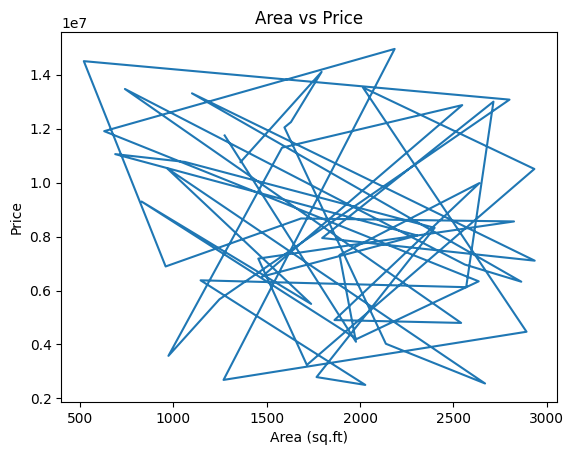

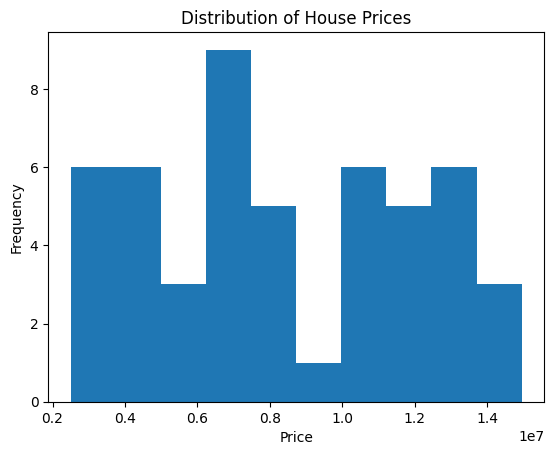

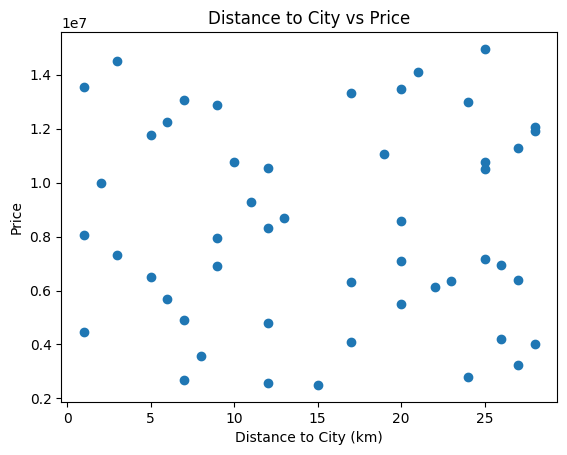

In [ ]:
import matplotlib.pyplot as plt

# 1. Line plot: Area vs Price
plt.figure()
plt.plot(df["Area"], df["Price"])
plt.xlabel("Area (sq.ft)")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.show()

# 2. Histogram of Price
plt.figure()
plt.hist(df["Price"], bins=10)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of House Prices")
plt.show()

# 3. Scatter plot: Distance to City vs Price
plt.figure()
plt.scatter(df["Distance_to_City"], df["Price"])
plt.xlabel("Distance to City (km)")
plt.ylabel("Price")
plt.title("Distance to City vs Price")
plt.show()


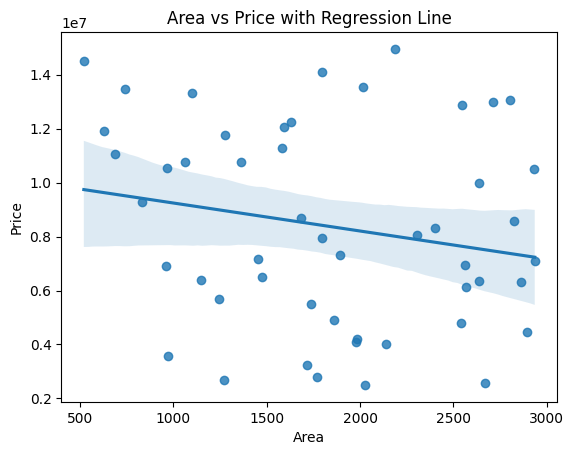

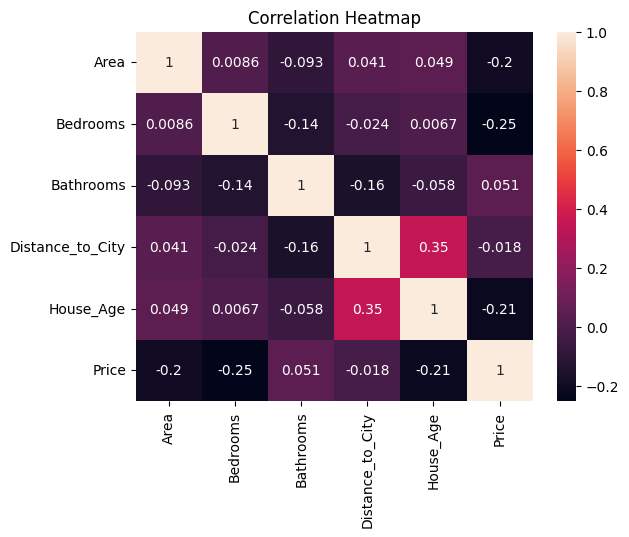

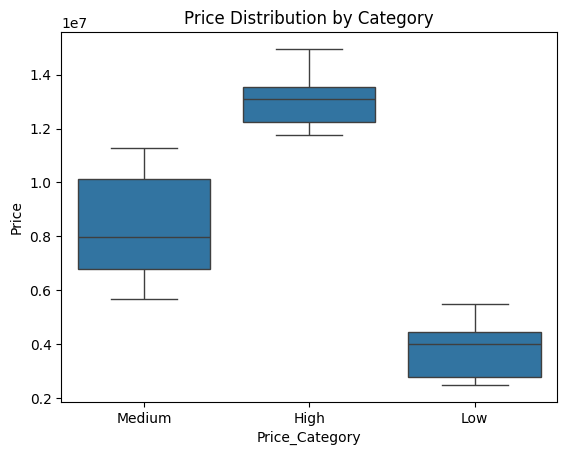

In [ ]:
import seaborn as sns

# 1. Scatter plot with regression line
plt.figure()
sns.regplot(x="Area", y="Price", data=df)
plt.title("Area vs Price with Regression Line")
plt.show()

# 2. Correlation heatmap
plt.figure()
corr = df.select_dtypes(include="number").corr()
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

# 3. Boxplot: Price by Category
plt.figure()
sns.boxplot(x="Price_Category", y="Price", data=df)
plt.title("Price Distribution by Category")
plt.show()


X_scaled = (X - mean) / standard_deviation

X_scaled = (X - min) / (max - min)


In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Separate features and target
X = df.drop(columns=["Price", "Price_Category"])
y = df["Price"]

# Standard Scaling
standard_scaler = StandardScaler()
X_standard_scaled = standard_scaler.fit_transform(X)

# Min-Max Scaling
minmax_scaler = MinMaxScaler()
X_minmax_scaled = minmax_scaler.fit_transform(X)

print("Standard Scaled Features (first 5 rows):")
print(X_standard_scaled[:5])

print("\nMin-Max Scaled Features (first 5 rows):")
print(X_minmax_scaled[:5])


Standard Scaled Features (first 5 rows):
[[-0.6835169   0.11162911 -1.36473196  1.10068479 -0.23237415]
 [-0.06304768 -1.28373482  0.94837305  0.64491469 -1.45111968]
 [-0.2975107   0.80931108  0.94837305 -1.06422318 -1.45111968]
 [-0.34754854 -0.58605285 -0.20817945  1.44251236  0.66137258]
 [ 0.42875281  0.80931108 -1.36473196  1.44251236  0.25512407]]

Min-Max Scaled Features (first 5 rows):
[[0.34755592 0.5        0.         0.88888889 0.41025641]
 [0.52734051 0.         1.         0.74074074 0.02564103]
 [0.45940348 0.75       1.         0.18518519 0.02564103]
 [0.44490472 0.25       0.5        1.         0.69230769]
 [0.66984258 0.75       0.         1.         0.56410256]]
